In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from src.config import PROCESSED_DATA_DIR
from src.data_utils import read_panel
from src.garch_methods import garch_forecasts

us = read_panel(PROCESSED_DATA_DIR / "us_portfolio.csv")["return"]
india = read_panel(PROCESSED_DATA_DIR / "india_portfolio.csv")["return"]

us_pct = us * 100
india_pct = india * 100

In [3]:
print("Computing US GARCH...")
us_garch = garch_forecasts(us_pct, asymmetric = False)
print(f" Done: {len(us_garch)} forecasts")

print("Computing US GJR-GARCH...")
us_gjr = garch_forecasts(us_pct, asymmetric = True)
print(f"Done {len(us_gjr)} forecasts")

print("Computing India GARCH...")
india_garch = garch_forecasts(india_pct, asymmetric = False)
print(f" Done: {len(india_garch)} forecasts")

print("Computing India GJR-GARCH...")
india_gjr = garch_forecasts(india_pct, asymmetric = True)
print(f"Done {len(india_gjr)} forecasts")

Computing US GARCH...
 Done: 3523 forecasts
Computing US GJR-GARCH...
Done 3523 forecasts
Computing India GARCH...
 Done: 3449 forecasts
Computing India GJR-GARCH...
Done 3449 forecasts


In [4]:
z_95 = stats.norm.ppf(0.05)
z_99 = stats.norm.ppf(0.01)

us_garch_var_95 = -us_garch["forecast_vol"] * z_95 / 100
us_garch_es_95 = us_garch["forecast_vol"] * stats.norm.pdf(z_95) / 0.05 / 100
us_garch_var_99 = -us_garch["forecast_vol"] * z_99 / 100
us_garch_es_99 = us_garch["forecast_vol"] * stats.norm.pdf(z_99) / 0.01 / 100

us_gjr_var_95 = -us_gjr["forecast_vol"] * z_95 / 100
us_gjr_es_95 = us_gjr["forecast_vol"] * stats.norm.pdf(z_95) / 0.05 / 100
us_gjr_var_99 = -us_gjr["forecast_vol"] * z_99 / 100
us_gjr_es_99 = us_gjr["forecast_vol"] * stats.norm.pdf(z_99) / 0.01 / 100

india_garch_var_95 = -india_garch["forecast_vol"] * z_95 / 100
india_garch_es_95 = india_garch["forecast_vol"] * stats.norm.pdf(z_95) / 0.05 / 100
india_garch_var_99 = -india_garch["forecast_vol"] * z_99 / 100
india_garch_es_99 = india_garch["forecast_vol"] * stats.norm.pdf(z_99) / 0.01 / 100

india_gjr_var_95 = -india_gjr["forecast_vol"] * z_95 / 100
india_gjr_es_95 = india_gjr["forecast_vol"] * stats.norm.pdf(z_95) / 0.05 / 100
india_gjr_var_99 = -india_gjr["forecast_vol"] * z_99 / 100
india_gjr_es_99 = india_gjr["forecast_vol"] * stats.norm.pdf(z_99) / 0.01 / 100

print("Converted GARCH variance to VaR/ES.")

Converted GARCH variance to VaR/ES.


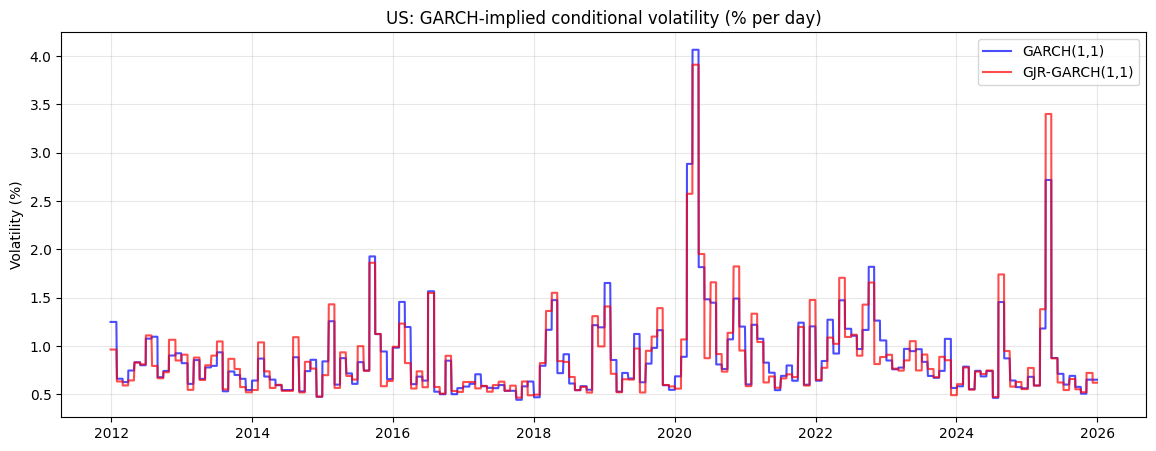

In [5]:
plt.figure(figsize = (14, 5))
plt.plot(us_garch.index, us_garch["forecast_vol"], label = "GARCH(1,1)", color = "blue", alpha = 0.7)
plt.plot(us_gjr.index, us_gjr["forecast_vol"], label = "GJR-GARCH(1,1)", color = "red", alpha = 0.7)
plt.title("US: GARCH-implied conditional volatility (% per day)")
plt.ylabel("Volatility (%)")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

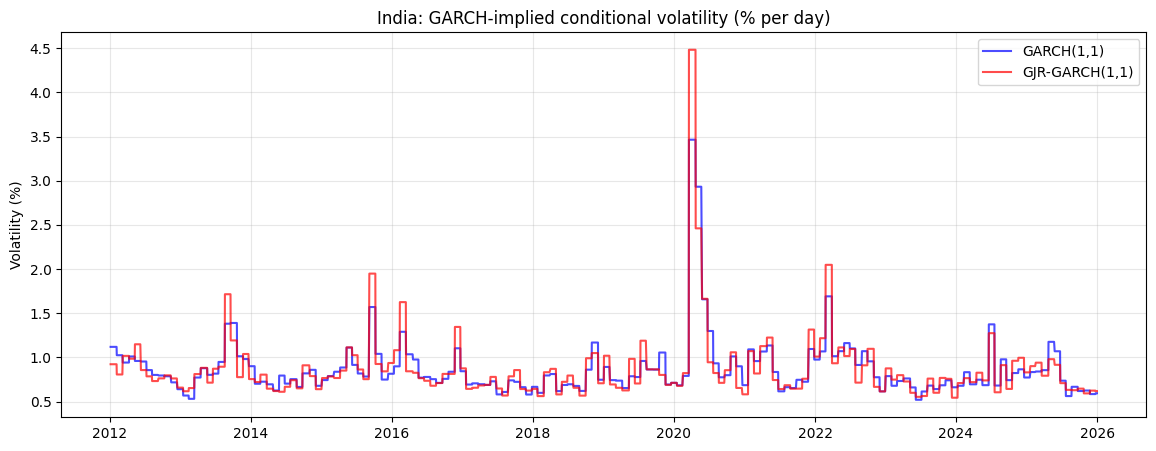

In [6]:
plt.figure(figsize = (14, 5))
plt.plot(india_garch.index, india_garch["forecast_vol"], label = "GARCH(1,1)", color = "blue", alpha = 0.7)
plt.plot(india_gjr.index, india_gjr["forecast_vol"], label = "GJR-GARCH(1,1)", color = "red", alpha = 0.7)
plt.title("India: GARCH-implied conditional volatility (% per day)")
plt.ylabel("Volatility (%)")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

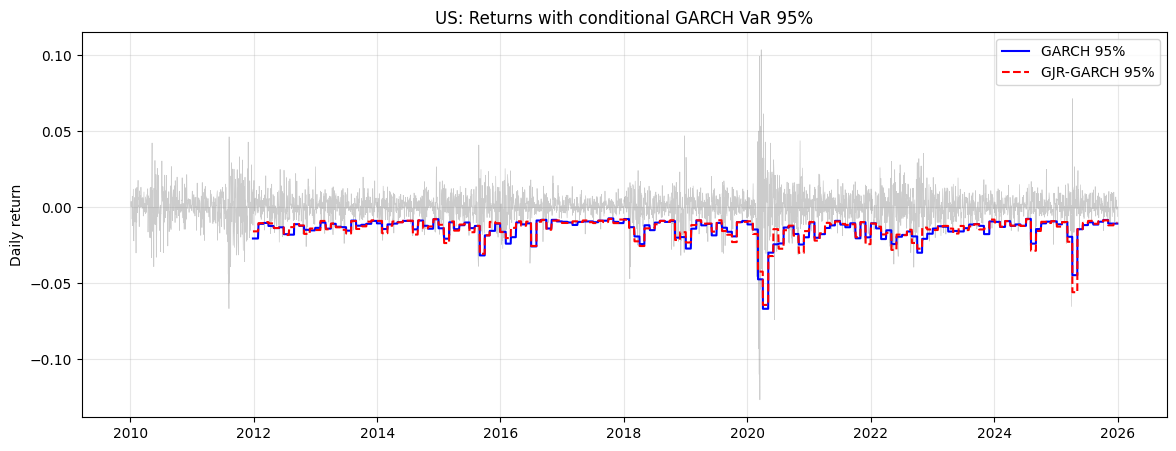

In [7]:
plt.figure(figsize = (14, 5))
plt.plot(us.index, us, color = "gray", alpha = 0.4, linewidth = 0.5)
plt.plot(us_garch_var_95.index, -us_garch_var_95, color = "blue", label = "GARCH 95%")
plt.plot(us_gjr_var_95.index, -us_gjr_var_95, linestyle = "--", color = "red", label = "GJR-GARCH 95%")
plt.title("US: Returns with conditional GARCH VaR 95%")
plt.ylabel("Daily return")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

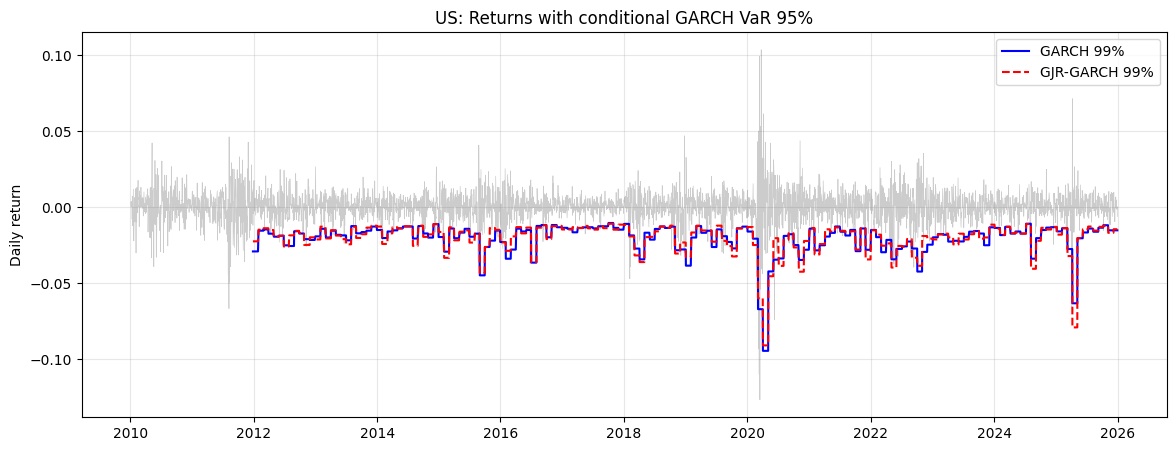

In [8]:
plt.figure(figsize = (14, 5))
plt.plot(us.index, us, color = "gray", alpha = 0.4, linewidth = 0.5)
plt.plot(us_garch_var_99.index, -us_garch_var_99, color = "blue", label = "GARCH 99%")
plt.plot(us_gjr_var_99.index, -us_gjr_var_99, linestyle = "--", color = "red", label = "GJR-GARCH 99%")
plt.title("US: Returns with conditional GARCH VaR 95%")
plt.ylabel("Daily return")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

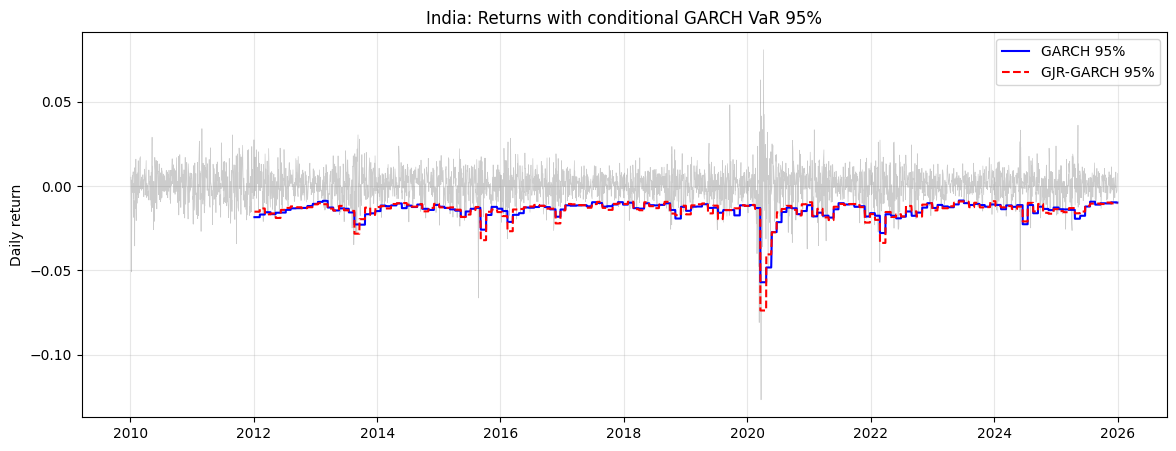

In [9]:
plt.figure(figsize = (14, 5))
plt.plot(india.index, india, color = "gray", alpha = 0.4, linewidth = 0.5)
plt.plot(india_garch_var_95.index, -india_garch_var_95, color = "blue", label = "GARCH 95%")
plt.plot(india_gjr_var_95.index, -india_gjr_var_95, linestyle = "--", color = "red", label = "GJR-GARCH 95%")
plt.title("India: Returns with conditional GARCH VaR 95%")
plt.ylabel("Daily return")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

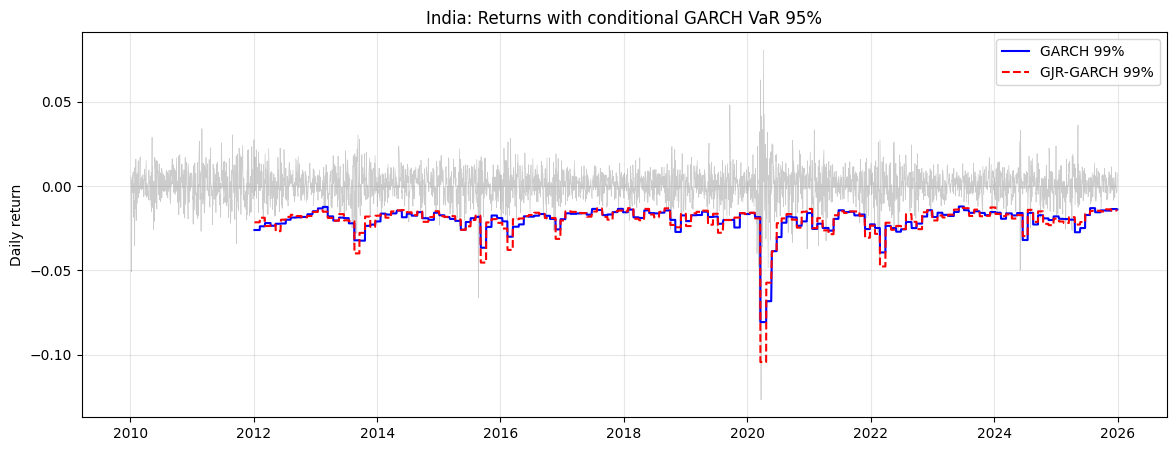

In [10]:
plt.figure(figsize = (14, 5))
plt.plot(india.index, india, color = "gray", alpha = 0.4, linewidth = 0.5)
plt.plot(india_garch_var_99.index, -india_garch_var_99, color = "blue", label = "GARCH 99%")
plt.plot(india_gjr_var_99.index, -india_gjr_var_99, linestyle = "--", color = "red", label = "GJR-GARCH 99%")
plt.title("India: Returns with conditional GARCH VaR 95%")
plt.ylabel("Daily return")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

In [12]:
us_garch.to_csv(PROCESSED_DATA_DIR / "us_garch_forecasts.csv")
us_gjr.to_csv(PROCESSED_DATA_DIR / "us_gjr_forecasts.csv")
india_garch.to_csv(PROCESSED_DATA_DIR / "india_garch_forecasts.csv")
india_gjr.to_csv(PROCESSED_DATA_DIR / "india_gjr_forecasts.csv")

pd.DataFrame({"var": us_garch_var_95, "es": us_garch_es_95}).to_csv(PROCESSED_DATA_DIR / "us_garch_var_95.csv")
pd.DataFrame({"var": us_garch_var_99, "es": us_garch_es_99}).to_csv(PROCESSED_DATA_DIR/ "us_garch_var_99.csv")
pd.DataFrame({"var": us_gjr_var_95, "es": us_gjr_es_95}).to_csv(PROCESSED_DATA_DIR / "us_gjr_var_95.csv")
pd.DataFrame({"var": us_gjr_var_99, "es": us_gjr_es_99}).to_csv(PROCESSED_DATA_DIR / "us_gjr_var_99.csv")
pd.DataFrame({"var": india_garch_var_95, "es": india_garch_es_95}).to_csv(PROCESSED_DATA_DIR / "india_garch_var_95.csv")
pd.DataFrame({"var": india_garch_var_99, "es": india_garch_es_99}).to_csv(PROCESSED_DATA_DIR / "india_garch_var_99.csv")
pd.DataFrame({"var": india_gjr_var_95, "es": india_gjr_es_95}).to_csv(PROCESSED_DATA_DIR / "india_gjr_var_95.csv")
pd.DataFrame({"var": india_gjr_var_99, "es": india_gjr_es_99}).to_csv(PROCESSED_DATA_DIR / "india_gjr_var_99.csv")

print("Saved.")

Saved.
